In [1]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

caminho = 'data/Consumo_mensal.xlsx'
excel = pd.ExcelFile(caminho)
print("Abas encontradas no arquivo:", excel.sheet_names)

Abas encontradas no arquivo: ['TOTAL', 'RESIDENCIAL', 'INDUSTRIAL', 'COMERCIAL', 'OUTROS', 'CATIVO', 'LIVRE', 'CONSUMIDORES TOTAIS', 'CONSUMIDORES RESIDENCIAIS', 'CONSUMIDORES INDUSTRIAIS', 'CONSUMIDORES COMERCIAIS', 'CONSUMIDORES OUTROS', 'CONSUMIDORES CATIVOS', 'CONSUMIDORES LIVRES', 'INDUSTRIAL GENERO', 'CONSUMO POR UF', 'CONSUMO CATIVO POR UF', 'CONSUMO LIVRE POR UF', 'CONSUMO RESIDENCIAL POR UF', 'CONSUMO INDUSTRIAL POR UF', 'CONSUMO COMERCIAL POR UF', 'CONSUMO OUTROS POR UF', 'CONSUMIDORES RES. POR UF', 'CONSUMIDORES INDUSTRIAIS POR UF', 'CONSUMIDORES COMERCIAIS POR UF', 'CONSUMIDORES OUTROS POR UF', 'CONSUMIDORES CATIVOS POR UF', 'CONSUMIDORES LIVRES POR UF']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
caminho = 'data/Consumo_mensal.xlsx'
#Lendo a aba especifica de gastos residenciais
df = pd.read_excel(caminho,sheet_name = 'RESIDENCIAL', header=5)

#Ajustando a coluna e filtrando ruídos e títulos
df.rename(columns={df.columns[0]: 'Regiao'}, inplace = True)
df = df.dropna(subset=['Regiao'])
df = df[~df['Regiao'].astype(str).str.contains('REGIÃO|SUBSISTEMA', case = False, na = False)]

#Filtrando as regioes a serem lidas
regioes_validas = ['Norte','Nordeste','Sudeste','Sul','Centro-Oeste']
df_limpo = df[df['Regiao'].isin(regioes_validas)].copy()

#Removendo a coluna ANO
df_limpo = df_limpo.dropna(axis=1, how='all')
if 'ANO' in df_limpo.columns:
    df_limpo = df_limpo.drop(columns=['ANO'])
#Transformar a coluna de meses em linhas
m_colunas = [c for c in df_limpo.columns if c != 'Regiao']
df_2 = df_limpo.melt(id_vars = ['Regiao'],
                     value_vars = m_colunas,
                     var_name = 'Mes',
                     value_name = 'Consumo_MWh')
df_2['Consumo_MWh'] = pd.to_numeric(df_2['Consumo_MWh'], errors = 'coerce')

                    



print("Colunas presentes em df_2:", df_2.columns.tolist())
df_2.head(10)

Colunas presentes em df_2: ['Regiao', 'Mes', 'Consumo_MWh']


,Regiao,Mes,Consumo_MWh
0,Norte,JAN,1193981.647
1,Nordeste,JAN,3374101.790
2,Sudeste,JAN,7814175.188
3,Sul,JAN,3083083.306
4,Centro-Oeste,JAN,1524369.851
5,Norte,JAN,1372158.401
6,Nordeste,JAN,2913218.014
7,Sul,JAN,3083083.306
8,Norte,JAN,1114404.424
9,Nordeste,JAN,3236557.183


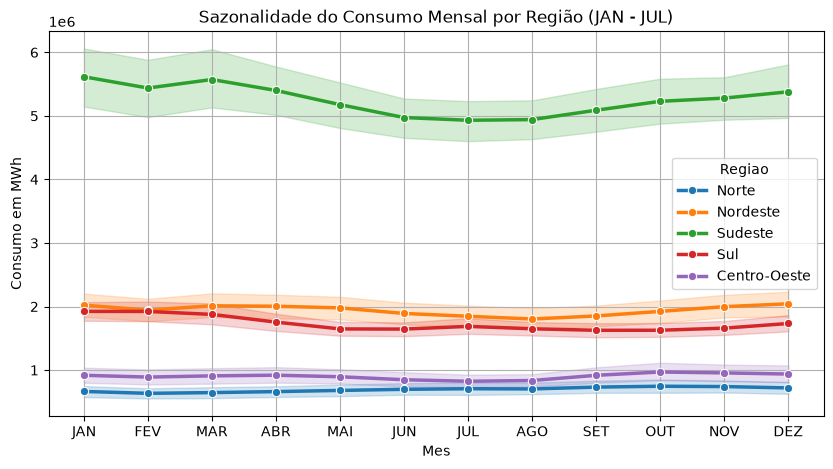

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
#Grafico1
plt.figure(figsize = (10,5))

sns.lineplot(
    data = df_2,
    x = 'Mes',
    y = 'Consumo_MWh',
    hue = 'Regiao',
    marker = 'o',
    linewidth = 2.5)

plt.title('Sazonalidade do Consumo Mensal por Região (JAN - JUL)')
plt.xlabel('Mes')
plt.ylabel('Consumo em MWh')
plt.grid(True)
plt.savefig('data/Sazonalidade_Consumo.png')
plt.show()

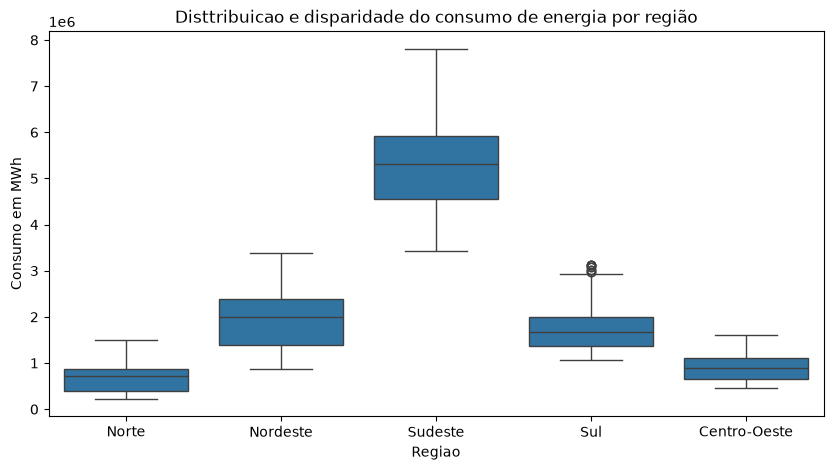

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
#Grafico 2
plt.figure(figsize = (10,5))

sns.boxplot(data = df_2, x='Regiao', y='Consumo_MWh')

plt.title('Disttribuicao e disparidade do consumo de energia por região')
plt.ylabel('Consumo em MWh')
plt.savefig('data/Disparidade_Regional.png')
plt.show()

In [6]:
#Aqui quantificaremos a oscilacao de consumo calculando o fator pico/vale
resumo = df_2.groupby('Regiao')['Consumo_MWh'].agg(
    Media = 'mean',
    Desvio_padrao = 'std',
    Minimo = 'min',
    Maximo = 'max',).reset_index()

resumo['Fator_Pico_Vale'] = resumo['Maximo'] / resumo['Minimo']
resumo = resumo.sort_values(by = 'Media', ascending = False)
resumo


,Regiao,Media,Desvio_padrao,Minimo,Maximo,Fator_Pico_Vale
3,Sudeste,5.253414e+06,960255.523026,3433442.490,7814175.188,2.275901
1,Nordeste,1.943116e+06,613832.870236,875228.766,3374101.790,3.855108
4,Sul,1.730314e+06,456882.888342,1056850.181,3131191.148,2.962758
0,Centro-Oeste,9.007603e+05,292544.346101,466358.820,1604542.685,3.440575
2,Norte,6.929688e+05,312445.679053,229864.282,1499186.314,6.522050


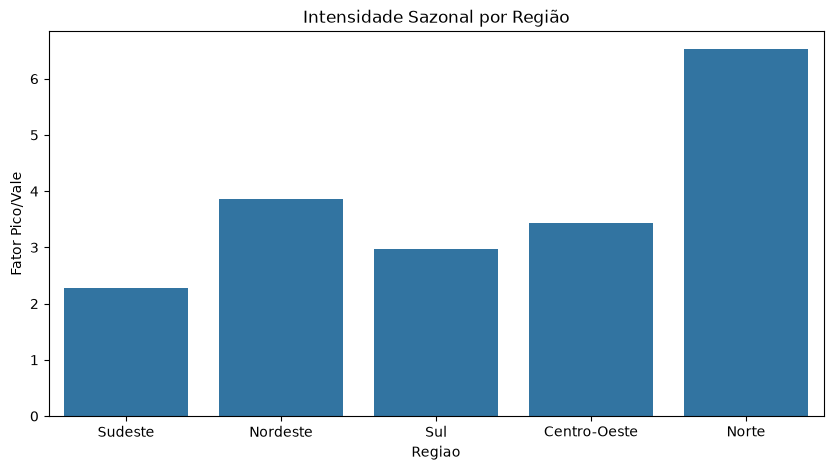

In [7]:
#Grafico 3

plt.figure(figsize = (10,5))

sns.barplot(data=resumo, x='Regiao', y='Fator_Pico_Vale')
plt.title('Intensidade Sazonal por Região')
plt.ylabel('Fator Pico/Vale')
plt.savefig('data/fator_pico_vale.png')
plt.show()



In [8]:
from scipy import stats

# Filtrando o consumo de energia do Sudeste no Verão e Inverno
verao = df_2[(df_2['Regiao'] == 'Sudeste') & (df_2['Mes'].isin(['JAN', 'FEV', 'MAR']))]['Consumo_MWh'].dropna()
inverno = df_2[(df_2['Regiao'] == 'Sudeste') & (df_2['Mes'].isin(['JUN', 'JUL', 'AGO']))]['Consumo_MWh'].dropna()

# Aplicando teste t de Student para amostras independentes
stat, p_valor = stats.ttest_ind(verao, inverno)

print(f"Estatística t: {stat:.4f}")
print(f"p-valor: {p_valor:.6f}")

if p_valor < 0.05:
    print("\nConclusão: Existe diferença estatisticamente significativa entre o consumo de Verão e Inverno no Sudeste (p < 0.05).")

Estatística t: 3.6249
p-valor: 0.000408

Conclusão: Existe diferença estatisticamente significativa entre o consumo de Verão e Inverno no Sudeste (p < 0.05).


In [9]:

#Salvando a tabela pronta na pasta data
df_2.to_csv('data/consumo_residencial_processado.csv', index=False)
print("Arquivo salvo com sucesso em data/consumo_residencial_processado.csv!")

Arquivo salvo com sucesso em data/consumo_residencial_processado.csv!


-Conclusão

Pergunta:
O consumo residencial de energia elétrica apresenta um padrão sazonal claramente identificável, e esse padrão varia entre as regiões brasileiras?

Resposta:
Sim. A Análise Exploratória e a inferência estatística confirmam que o padrão sazonal varia de forma expressiva entre as regiões do país.

Recomendação:
Portanto, a recomendação é que a instituição de planejamento energético concentre o planejamento operacional, as campanhas de eficiência energética e a manutenção da malha elétrica nas regiões Sul e Sudeste para suportar os picos de demanda no Verão, enquanto as regiões Norte e Nordeste demandam investimentos voltados à expansão contínua da infraestrutura de rede para que se aproximem da realidade dos outros estados em vez de medidas paliativas, visto que não apresentam sazonalidade climática expressiva. Fora isso, a região Centro-Oeste se encontra em um realidade híbrida, devendo ser mantida sob monitoramento contínuo sem demandar o foco prioritário das contingências.